<a href="https://colab.research.google.com/github/gonzaaloo/PAS/blob/main/PAS_Gonzalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# **PAS**
El Paseao Aleatorio Simple de parámetro p es un ejemplo de proceso estocástico en T = ℕ. Tomando valores en S = ℤ.
Para cada *t* ∈ℕ, se considera:
*Xₜ = $\sum_{s=1}^{t}$Zₛ*.
 Siendo  $\{Z_s\}_{s \in \mathbb{N}}$ variables aleatorias independientes
 idénticamente distribuidas, según la distribución: *P(Zₛ = 1) = p, P(Zₛ =−1)=1−p.*



In [2]:
def simular_PAS(p, n, reps):
 # p : probabilidad de que el pas tome valor 1(análogamente, probabilidad 1-p de que tome el valor -1)
 # n : número de pasos que tomamos a lo largo del PAS.
 # reps : es el número de repeticiones del PAS, con distintos valores y misma probabilidad p.

 # Vamos a entender un poco lo que necesitamos, queríamos una matriz que nos diera valores aleatorios
 # y que estos fuesen variando entre los valores 1 y -1, como estábamos en trabajando con el PAS
 # entonces asociamos la probabilidades mencionadas antes en función del valor de la variable.
 # Para el output necesitaremos una matriz que tenga sumados en cada columna la suma de todos los
 # valores de la variable de cada reps hasta un cierto paso <=n, llegando hasta
 # los n pasos como vimos en clase, este valor podrá ser un valor comprendido entre +-n.
 # Para ello nos ayudamos de una de las funciones vistas en el tutorial de NumPy como es la generadora
 # de matrices de números aleatorios comprendidos en el intervalo [0,1)
  generador_numeros = np.random.rand(reps, n)

  # Con esta función where vista en el apartado 4.8: NumPy Comparison Operators and Masks del tutorial,
  # convertimos los números aleatorios en 1 o -1 según la probabilidad 'p'
  # ·Si el número aleatorio <= p, el paso es 1
  # ·Si el número aleatorio > p, el paso es -1
  pasos = np.where(generador_numeros <= p, 1, -1)

  # Pedimos a la IA que nos de una función de NumPy que nos de una suma acumulada de los pasos(por filas(axis=1))
  # en cada repetición, pues para dibujar la gráfica necesitamos la suma de todos los pasos del camino.
  # La opción alternativa que se parecía más a lo que había visto en la asignatura de informática ii(con C++)
  # era la multiplicación de la matriz de pasos por una triangular superior de 1's.
  pasos_acumulados = np.cumsum(pasos, axis=1)

  return pasos_acumulados



# **Visualización 1**

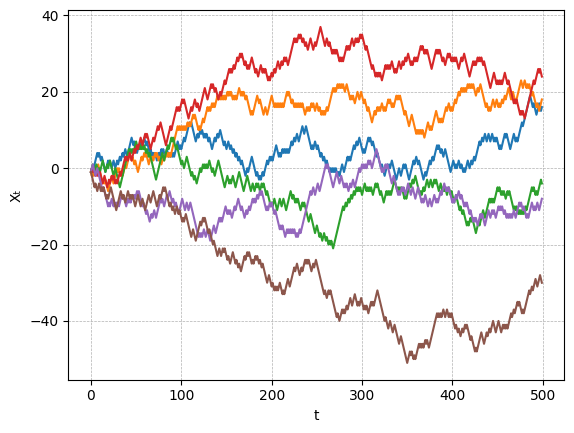

In [3]:
pasos_acumulados = simular_PAS(p=0.5, n=500, reps=6)

# Cogemos un modelo de la librería de Matplotlib y lo modificamos para obtener
# un gráfica que nos muestre cómo evolucionan 6 reps de paseo aleatorio
# simple con la misma probabilidad.

plt.plot(pasos_acumulados.T)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle = '--', linewidth=0.5)
plt.show()

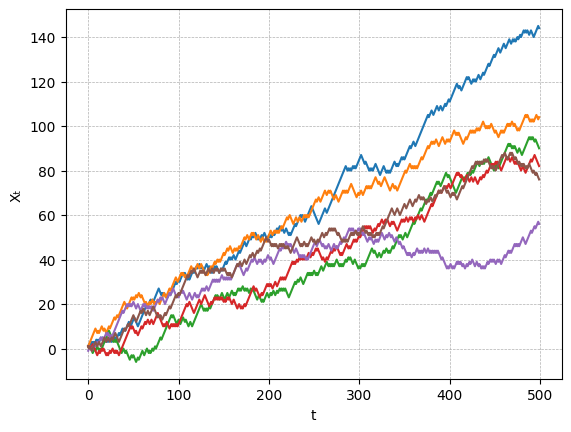

In [4]:
pasos_acumulados = simular_PAS(p=0.6, n=500, reps=6)

plt.plot(pasos_acumulados.T)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle = '--', linewidth=0.5)
plt.show()

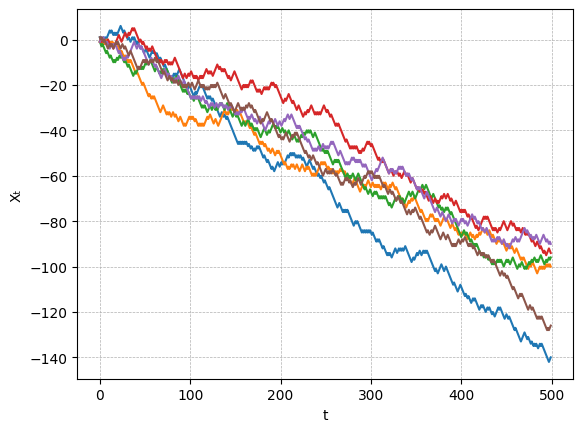

In [5]:
pasos_acumulados = simular_PAS(p=0.4, n=500, reps=6)


plt.plot(pasos_acumulados.T)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle = '--', linewidth=0.5)
plt.show()

# **Visualización 2**

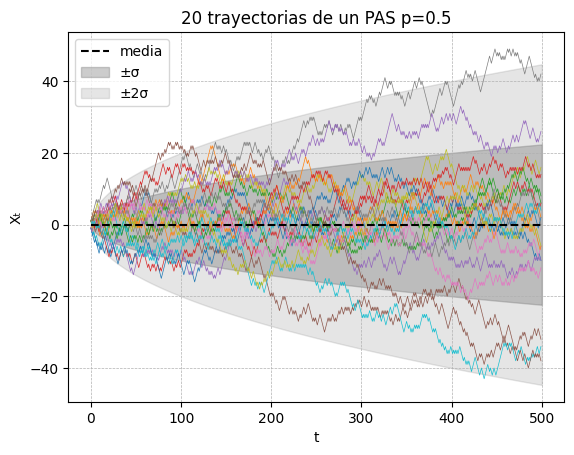

In [6]:
pasos_acumulados = simular_PAS(p=0.5, n=500, reps=20)

# Calculamos las media y la varianza de las 500 pasos del PAS, para ello definimos dos funciones
p = 0.5
def media(x):
  return x*(2*p-1)

def desv_tip(x):
  return np.sqrt(x*(4*p*(1-p)))

dibujo = np.linspace(0,500,500)
x_media = media(dibujo)
x_desv_tip = desv_tip(dibujo)

# Dibujamos
plt.plot(pasos_acumulados.T, linewidth=0.5)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle='--', linewidth=0.5)

plt.title( '20 trayectorias de un PAS p=0.5')

plt.plot(dibujo, x_media, color='black', linestyle='--', label ='media')
# Dibujamos el área de las desviaciones tipicas, en este caso la media es 0 y las desv típcas tienen el eje en el y=0
plt.fill_between(dibujo, x_desv_tip, -x_desv_tip, color = 'grey', alpha=0.4, label='±σ')
plt.fill_between(dibujo, 2*x_desv_tip,-2*x_desv_tip, color = 'grey', alpha=0.2, label='±2σ')

plt.legend(loc='upper left')
plt.show()

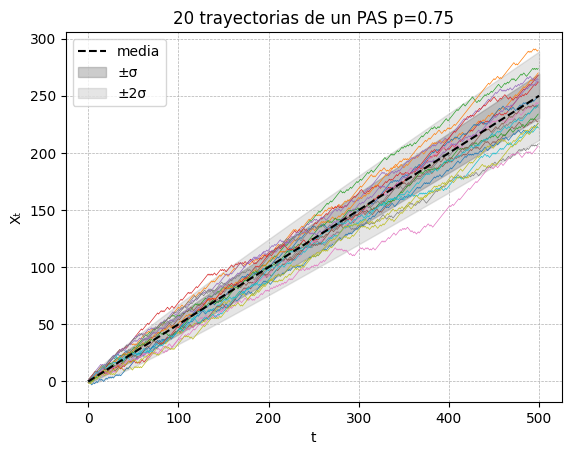

In [7]:
pasos_acumulados = simular_PAS(p=0.75, n=500, reps=20)

# Calculamos las media y la varianza del PAS, para ello definimos dos funciones
p = 0.75
def media(x):
  return x*(2*p-1)

def desv_tip(x):
  return np.sqrt(x*(4*p*(1-p)))

dibujo = np.linspace(0,500,500)
x_media = media(dibujo)
x_desv_tip = desv_tip(dibujo)

plt.plot(pasos_acumulados.T, linewidth=0.5)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle='--',linewidth=0.5)

plt.title( '20 trayectorias de un PAS p=0.75')

plt.plot(dibujo, x_media, color='black', linestyle='--', label='media')
# Sumamos la media a las desv tipicas porque el eje de las parábolas es la recta de la media
plt.fill_between(dibujo, x_media + x_desv_tip, x_media - x_desv_tip, color = 'grey', alpha=0.4, label='±σ')
plt.fill_between(dibujo, x_media + 2*x_desv_tip,x_media - 2*x_desv_tip, color = 'grey', alpha=0.2, label='±2σ')

plt.legend(loc='upper left')
plt.show()

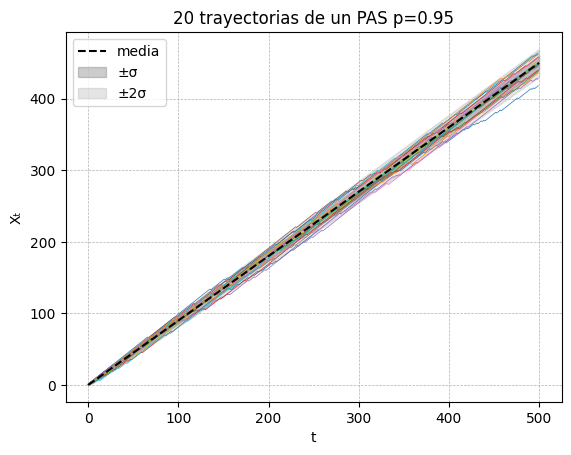

In [8]:
pasos_acumulados = simular_PAS(p=0.95, n=500, reps=20)

# Calculamos las media y la varianza del PAS, para ello definimos dos funciones
p = 0.95
def media(x):
  return x*(2*p-1)

def desv_tip(x):
  return np.sqrt(x*(4*p*(1-p)))

dibujo = np.linspace(0,500,500)
x_media = media(dibujo)
x_desv_tip = desv_tip(dibujo)

plt.plot(pasos_acumulados.T, linewidth=0.5)
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle='--', linewidth=0.5)

plt.title('20 trayectorias de un PAS p=0.95')

plt.plot(dibujo, x_media, color='black', linestyle='--', label = "media")
# Sumamos la media a las desv tipicas porque el eje de las parábolas es la recta de la media
plt.fill_between(dibujo, x_media + x_desv_tip, x_media - x_desv_tip, color = 'grey', alpha=0.4, label="±σ")
plt.fill_between(dibujo, x_media + 2*x_desv_tip,x_media - 2*x_desv_tip, color = 'grey', alpha=0.2, label="±2σ")

plt.legend(loc='upper left')
plt.show()

# **Visualizacíon 3**

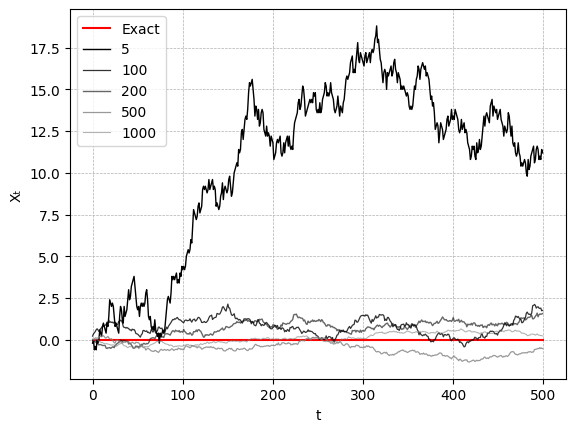

In [10]:
plt.xlabel('t')
plt.ylabel('Xₜ')
plt.grid(linestyle='--', linewidth=0.5)

# Calcular la media teórica
p = 0.5
def media_teorica(x):
  return x*(2*p-1)

dibujo_teorico = np.linspace(0,500,500)
x_media_teorica = media_teorica(dibujo_teorico)
plt.plot(dibujo_teorico, x_media_teorica, linewidth=1.5, color='red', label='Exact')

# Calculamos y dibujamos las medias empíricas para los diferentes valores de n.
# Para ello hacemos la media en cada paso de cada columna en cada paso y lo guardamos en un vector para después dibujarlo

# Para n=5
pasos_acumulados_5 = simular_PAS(p=0.5, n=500, reps=5)
media_empirica_5 = np.mean(pasos_acumulados_5, axis=0)
plt.plot(media_empirica_5, linewidth=1, color='black', label='5')

# Para n=100
pasos_acumulados_100 = simular_PAS(p=0.5, n=500, reps=100)
media_empirica_100 = np.mean(pasos_acumulados_100, axis=0)
plt.plot(media_empirica_100, linewidth=0.9, color='black', alpha=0.8, label='100')

# Para n=200
pasos_acumulados_200 = simular_PAS(p=0.5, n=500, reps=200)
media_empirica_200 = np.mean(pasos_acumulados_200, axis=0)
plt.plot(media_empirica_200, linewidth=1, color='black', alpha=0.6, label='200')

# Para n=500
pasos_acumulados_500 = simular_PAS(p=0.5, n=500, reps=500)
media_empirica_500 = np.mean(pasos_acumulados_500, axis=0)
plt.plot(media_empirica_500, linewidth=0.9, color='grey', alpha=0.8, label='500')

# Para n=1000
pasos_acumulados_1000 = simular_PAS(p=0.5, n=500, reps=1000)
media_empirica_1000 = np.mean(pasos_acumulados_1000, axis=0)
plt.plot(media_empirica_1000, linewidth=0.8, color='grey', alpha=0.6, label='1000')


plt.legend(loc='upper left')
plt.show()